# Chapter 9: Degree and Lefschetz Number

**Source orientation:** Armstrong, *Basic Topology*, Chapter 9, printed pp. 195-212, PDF pages approximately 203-220.

## Chapter Goal

This chapter turns homology from a classifier into a detector. A map of a sphere has a degree, a finite complex has an Euler-Poincare ledger, an antipodal symmetry has a mod-2 obstruction, and a self-map has a Lefschetz number. Each quantity is small, but each survives homotopy and can force a geometric event such as a fixed point, an antipodal coincidence, or a dimension obstruction.

The notebook is standalone. The source pages guided the sequence of ideas, but the prose, examples, code, diagrams, artifacts, and checks here are original and computational.

## Computational Translation Guide

| Topological idea | Computational model in this notebook | Checkable signal |
| --- | --- | --- |
| Degree of `S^n -> S^n` | Circle lifts and a homology generator multiplied by an integer | Net lift change and `deg(f o g) = deg(f) deg(g)` |
| Induced map on homology | A simplicial self-map of a triangulated circle acting on `C_0`, `C_1`, `H_0`, and `H_1` | Chain-map matrices and the image of a cycle generator |
| Euler-Poincare formula | Boundary matrices over the rationals for small complexes | Alternating simplex count equals alternating Betti count |
| Borsuk-Ulam intuition | The antipodal gap `f(x) - f(-x)` for a scalar map on `S^1` | The gap is odd under antipodes and must cross zero |
| Lefschetz number | Alternating traces on homology and, for simplicial maps, on chains | Hopf trace equality and fixed-point-forcing when `Lambda != 0` |
| Dimension invariance | Nerves of circle covers before and after refinement | Coarse nerves may overestimate, refined nerves recover dimension one |


In [1]:
from __future__ import annotations

from itertools import combinations
from pathlib import Path
import sys

import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, Polygon
import networkx as nx
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import sympy as sp


def find_book_root(start: Path) -> Path:
    candidates = [start, *start.parents, start / "Basic-Topology"]
    for candidate in candidates:
        if (candidate / "00-book-index.ipynb").exists() and (candidate / "utils").exists():
            return candidate.resolve()
    raise RuntimeError("Could not find Basic-Topology book root")


BOOK_ROOT = find_book_root(Path.cwd())
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.artifacts import artifact_path, assert_artifact, display_artifact, save_json, save_matplotlib, save_plotly_html

UNIT = "chapter-09"
FIG_DIR = artifact_path(UNIT, "figures", "placeholder.txt").parent
HTML_DIR = artifact_path(UNIT, "html", "placeholder.html").parent
CHECK_DIR = artifact_path(UNIT, "checks", "placeholder.json").parent
TABLE_DIR = artifact_path(UNIT, "tables", "placeholder.csv").parent

PALETTE = {
    "ink": "#243047",
    "muted": "#6b7280",
    "grid": "#d7dde8",
    "blue": "#2563eb",
    "teal": "#0f766e",
    "gold": "#b7791f",
    "red": "#dc2626",
    "green": "#15803d",
    "purple": "#7c3aed",
    "paper": "#fbfcfe",
}

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": PALETTE["paper"],
    "axes.edgecolor": PALETTE["grid"],
    "axes.labelcolor": PALETTE["ink"],
    "xtick.color": PALETTE["muted"],
    "ytick.color": PALETTE["muted"],
    "text.color": PALETTE["ink"],
    "font.size": 10,
})


def rel(path: str | Path) -> str:
    return Path(path).resolve().relative_to(BOOK_ROOT).as_posix()


BOOK_ROOT

WindowsPath('D:/Geometry/Basic-Topology')

## How to Read the Computations

The same pattern appears in every section. First choose a finite model that keeps the relevant topology visible: a lifted circle map, a triangulated circle, a boundary-matrix complex, a cover nerve, or a homology trace table. Then identify which data are allowed to change. Coordinates, subdivisions, labels, and the particular drawing are flexible. The invariant is the part that survives those changes.

This matters especially for the fixed-point results. A drawing may show a point that returns to itself, but the theorem is stronger: the homology trace can force such a point before we know where it is. Likewise, the Borsuk-Ulam plot is not a proof of the full theorem; it is a one-dimensional witness for the same obstruction. The antipodal gap cannot stay away from zero because its sign is reversed by the antipodal move.

For the dimension section, the computation warns against reading dimension from one convenient cover. A coarse cover can create a filled nerve that looks too large. The definition asks whether every cover can be refined until the nerve dimension is controlled. That is why the refined circle cover, not the coarse one, carries the intended lesson.

## Chapter-Specific Storyboard

The visuals below are not decorative. Each one attaches a chapter concept to a representation, an inspection target, and a validation check. Matplotlib is used for durable diagrams and matrix/table artifacts, Plotly is used for the interactive degree-composition lift, NetworkX is used for dependency and nerve graphs, SymPy is used for exact ranks and trace identities, and NumPy/Pandas handle the finite computations.


In [2]:
storyboard = pd.DataFrame([
    {
        "concept": "Degree of sphere maps",
        "representation": "Lift graphs for circle maps and a Plotly composition tracker",
        "library": "Matplotlib + Plotly",
        "inspection_target": "The slope/net turn of a lift is the integer degree",
        "check": "deg(f o g) = deg(f) deg(g)",
    },
    {
        "concept": "Induced homology map",
        "representation": "Triangulated circle chain matrices for a reflection",
        "library": "NumPy + Matplotlib",
        "inspection_target": "The cycle generator is multiplied by the degree",
        "check": "chain trace equals homology trace for simple maps",
    },
    {
        "concept": "Euler-Poincare",
        "representation": "Boundary-matrix ledger for point, circle, disk, sphere, figure eight",
        "library": "SymPy + Pandas + Matplotlib",
        "inspection_target": "Cell counts and Betti counts give the same alternating sum",
        "check": "chi_cells == chi_betti for each complex",
    },
    {
        "concept": "Borsuk-Ulam intuition",
        "representation": "Antipodal gap for a scalar function on S^1",
        "library": "NumPy + Matplotlib",
        "inspection_target": "The gap changes sign at antipodal points and crosses zero",
        "check": "gap(t + pi) = -gap(t) and at least one root appears",
    },
    {
        "concept": "Lefschetz number and fixed point index",
        "representation": "Alternating trace table and reflection fixed-point sketch",
        "library": "NumPy + NetworkX + Matplotlib",
        "inspection_target": "Nonzero Lefschetz number counts index contributions in the simple model",
        "check": "Lambda = sum (-1)^q trace(f_q*)",
    },
    {
        "concept": "Dimension by nerves",
        "representation": "Coarse and refined circle-cover nerves",
        "library": "NetworkX + Matplotlib",
        "inspection_target": "Refinement can lower the nerve dimension to match the circle",
        "check": "coarse nerve dimension 2, refined nerve dimension 1",
    },
])
storyboard

,concept,representation,library,inspection_target,check
0,Degree of sphere maps,Lift graphs for circle maps and a Plotly compo...,Matplotlib + Plotly,The slope/net turn of a lift is the integer de...,deg(f o g) = deg(f) deg(g)
1,Induced homology map,Triangulated circle chain matrices for a refle...,NumPy + Matplotlib,The cycle generator is multiplied by the degree,chain trace equals homology trace for simple maps
2,Euler-Poincare,"Boundary-matrix ledger for point, circle, disk...",SymPy + Pandas + Matplotlib,Cell counts and Betti counts give the same alt...,chi_cells == chi_betti for each complex
3,Borsuk-Ulam intuition,Antipodal gap for a scalar function on S^1,NumPy + Matplotlib,The gap changes sign at antipodal points and c...,gap(t + pi) = -gap(t) and at least one root ap...
4,Lefschetz number and fixed point index,Alternating trace table and reflection fixed-p...,NumPy + NetworkX + Matplotlib,Nonzero Lefschetz number counts index contribu...,Lambda = sum (-1)^q trace(f_q*)
5,Dimension by nerves,Coarse and refined circle-cover nerves,NetworkX + Matplotlib,Refinement can lower the nerve dimension to ma...,"coarse nerve dimension 2, refined nerve dimens..."


## Degree as Winding Detected by Homology

For a circle map, a lift is an angle-valued record of how the image winds around the target. If the lift starts at `F(0)` and ends at `F(2*pi)`, the quotient `(F(2*pi) - F(0))/(2*pi)` is the degree. This is the one-dimensional version of the chapter's homology definition: the top homology generator is sent to an integer multiple of itself.

The inspection target in the first artifact is the vertical net change of each lift. The identity has net change one, a double winding has net change two, a reflection has net change minus one, and a constant map has net change zero.


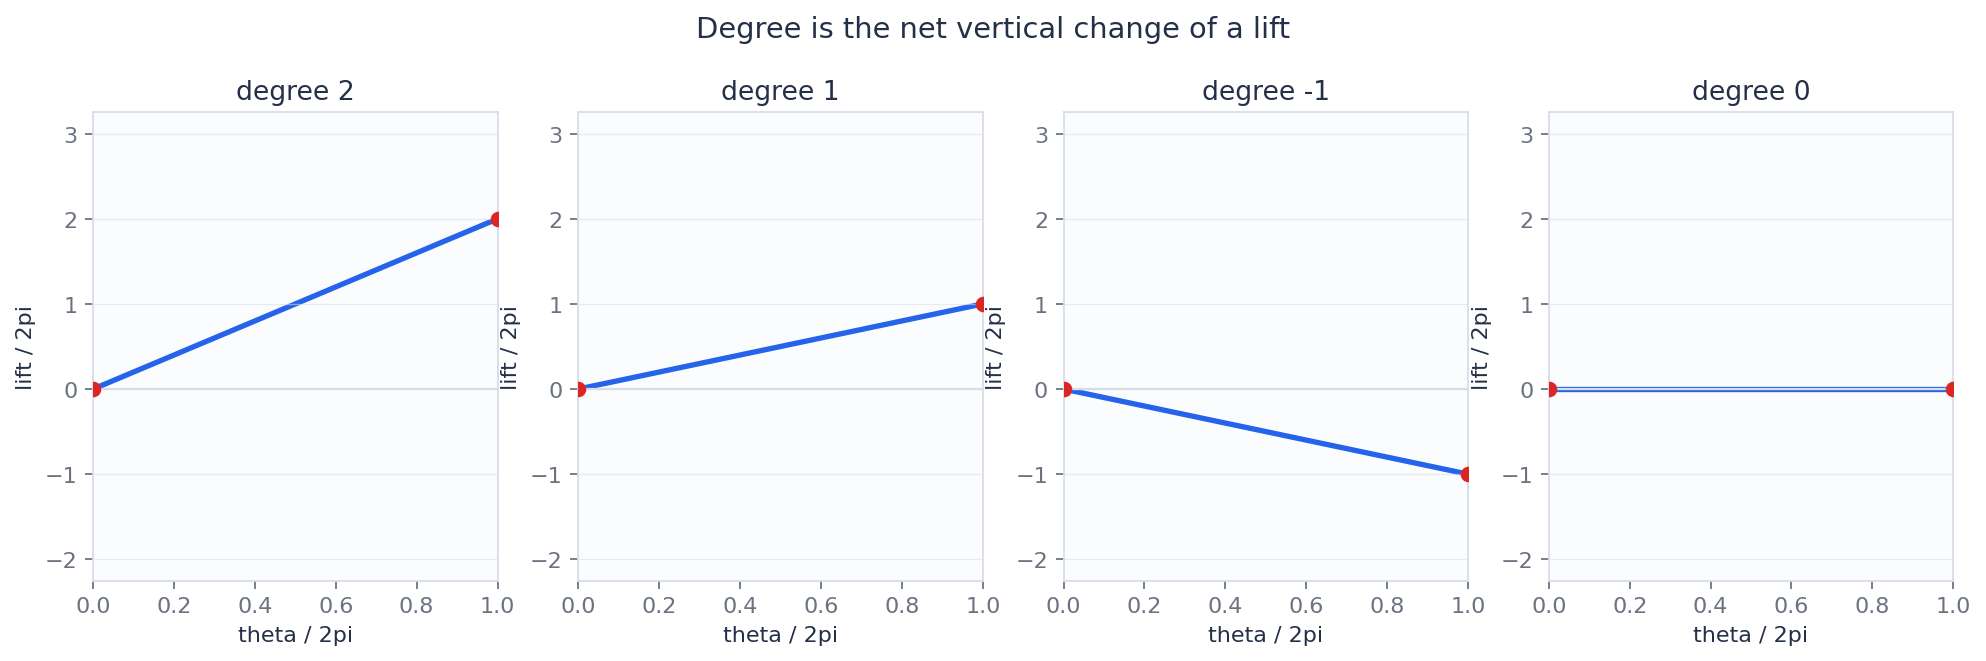

{'sample_degrees': {'z^2': 2, 'z^1': 1, 'z^-1': -1, 'constant': 0},
 'composition': {'deg_f': 3,
  'deg_g': -2,
  'deg_composite_from_lift': -6,
  'product': -6}}

In [3]:
theta = np.linspace(0, 2 * np.pi, 801)


def lifted_degree(angle_values: np.ndarray) -> int:
    unwrapped = np.unwrap(angle_values)
    return int(round((unwrapped[-1] - unwrapped[0]) / (2 * np.pi)))


def circle_lift(k: int, theta_values: np.ndarray = theta) -> np.ndarray:
    return k * theta_values


degree_examples = [2, 1, -1, 0]
computed_degrees = {f"z^{k}" if k != 0 else "constant": lifted_degree(circle_lift(k)) for k in degree_examples}

fig, axes = plt.subplots(1, len(degree_examples), figsize=(15, 3.8), sharex=True)
for ax, k in zip(axes, degree_examples):
    lift = circle_lift(k)
    ax.plot(theta / (2 * np.pi), lift / (2 * np.pi), color=PALETTE["blue"], lw=2.4)
    ax.axhline(0, color=PALETTE["grid"], lw=1)
    for integer in range(-2, 4):
        ax.axhline(integer, color=PALETTE["grid"], lw=0.6, alpha=0.55)
    ax.scatter([0, 1], [lift[0] / (2 * np.pi), lift[-1] / (2 * np.pi)], color=PALETTE["red"], zorder=3)
    label = f"degree {k}"
    if k == 0:
        label = "degree 0"
    ax.set_title(label)
    ax.set_xlabel("theta / 2pi")
    ax.set_ylabel("lift / 2pi")
    ax.set_xlim(0, 1)
    ax.grid(False)
fig.suptitle("Degree is the net vertical change of a lift", y=1.04, fontsize=13)
degree_fig = save_matplotlib(fig, UNIT, "figures", "degree-winding-lifts.png")
plt.close(fig)

deg_f = 3
deg_g = -2
lift_g = deg_g * theta
lift_f = deg_f * theta
lift_composite = deg_f * lift_g
composition_fig = go.Figure()
composition_fig.add_trace(go.Scatter(x=theta / (2 * np.pi), y=lift_f / (2 * np.pi), mode="lines", name="lift of f, degree 3"))
composition_fig.add_trace(go.Scatter(x=theta / (2 * np.pi), y=lift_g / (2 * np.pi), mode="lines", name="lift of g, degree -2"))
composition_fig.add_trace(go.Scatter(x=theta / (2 * np.pi), y=lift_composite / (2 * np.pi), mode="lines", name="lift of f o g, degree -6", line=dict(width=4)))
composition_fig.update_layout(
    title="Composition multiplies degree",
    xaxis_title="theta / 2pi",
    yaxis_title="lift / 2pi",
    template="plotly_white",
    height=470,
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="left", x=0),
)
composition_html = save_plotly_html(composition_fig, UNIT, "html", "degree-composition-multiplier.html")

degree_checks = {
    "sample_degrees": computed_degrees,
    "composition": {
        "deg_f": deg_f,
        "deg_g": deg_g,
        "deg_composite_from_lift": lifted_degree(lift_composite),
        "product": deg_f * deg_g,
    },
}

display_artifact(degree_fig, width=900)
display_artifact(composition_html, width="100%", height=500)
degree_checks

## Induced Maps on Chains and Homology

A simplicial map first acts on chains. Homology keeps only the cycle information that survives boundaries. On a triangulated circle, `H_0` records the single component and `H_1` is generated by one oriented loop. The reflection below sends that loop generator to its negative, so the induced map on `H_1` has trace `-1`.

This is also the simplest place to see the Hopf trace idea used in the Lefschetz theorem: the alternating trace on chains agrees with the alternating trace on homology.


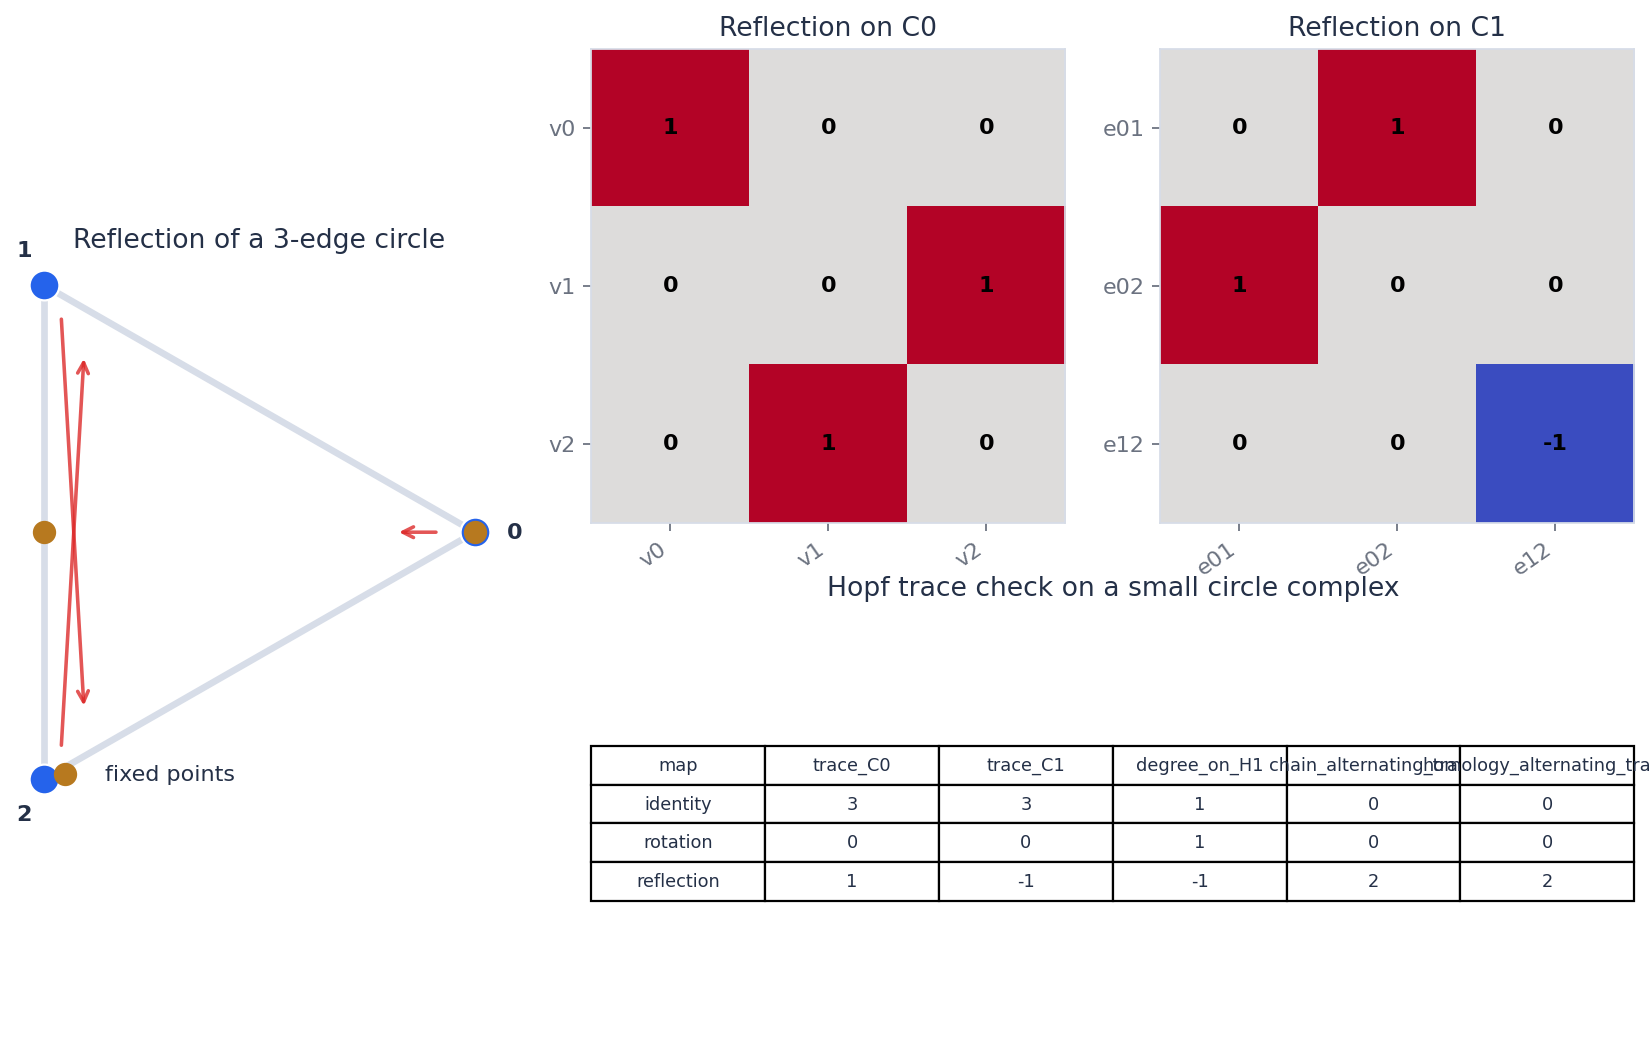

,map,trace_C0,trace_C1,degree_on_H1,chain_alternating_trace,homology_alternating_trace
0,identity,3,3,1,0,0
1,rotation,0,0,1,0,0
2,reflection,1,-1,-1,2,2


In [4]:
circle_0 = [(0,), (1,), (2,)]
circle_1 = [(0, 1), (0, 2), (1, 2)]
cycle_generator = np.array([1, -1, 1], dtype=int)  # e01 - e02 + e12


def permutation_sign(values: tuple[int, ...]) -> int:
    inversions = 0
    for i in range(len(values)):
        for j in range(i + 1, len(values)):
            inversions += int(values[i] > values[j])
    return -1 if inversions % 2 else 1


def chain_matrix(simplices: list[tuple[int, ...]], vertex_map: dict[int, int]) -> np.ndarray:
    target_index = {sigma: i for i, sigma in enumerate(simplices)}
    matrix = np.zeros((len(simplices), len(simplices)), dtype=int)
    for col, sigma in enumerate(simplices):
        image = tuple(vertex_map[v] for v in sigma)
        if len(set(image)) < len(image):
            continue
        sorted_image = tuple(sorted(image))
        row = target_index[sorted_image]
        order = tuple(sorted_image.index(v) for v in image)
        matrix[row, col] = permutation_sign(order)
    return matrix


def boundary_matrix(k_simplices: list[tuple[int, ...]], faces: list[tuple[int, ...]]) -> np.ndarray:
    face_index = {face: i for i, face in enumerate(faces)}
    matrix = np.zeros((len(faces), len(k_simplices)), dtype=int)
    for col, sigma in enumerate(k_simplices):
        for i in range(len(sigma)):
            face = sigma[:i] + sigma[i + 1 :]
            matrix[face_index[face], col] = -1 if i % 2 else 1
    return matrix


def degree_on_circle_h1(edge_matrix: np.ndarray) -> int:
    image = edge_matrix @ cycle_generator
    nonzero = np.flatnonzero(cycle_generator)
    ratios = [image[i] // cycle_generator[i] for i in nonzero]
    if not all(image[i] == ratios[0] * cycle_generator[i] for i in range(len(cycle_generator))):
        raise AssertionError(f"cycle generator was not scaled: {image}")
    return int(ratios[0])


circle_boundary = boundary_matrix(circle_1, circle_0)
assert np.array_equal(circle_boundary @ cycle_generator, np.zeros(3, dtype=int))

simplicial_maps = {
    "identity": {0: 0, 1: 1, 2: 2},
    "rotation": {0: 1, 1: 2, 2: 0},
    "reflection": {0: 0, 1: 2, 2: 1},
}

chain_rows = []
chain_data = {}
for name, vmap in simplicial_maps.items():
    m0 = chain_matrix(circle_0, vmap)
    m1 = chain_matrix(circle_1, vmap)
    h1_degree = degree_on_circle_h1(m1)
    chain_trace = int(np.trace(m0) - np.trace(m1))
    homology_trace = int(1 - h1_degree)
    chain_rows.append({
        "map": name,
        "trace_C0": int(np.trace(m0)),
        "trace_C1": int(np.trace(m1)),
        "degree_on_H1": h1_degree,
        "chain_alternating_trace": chain_trace,
        "homology_alternating_trace": homology_trace,
    })
    chain_data[name] = {"C0": m0, "C1": m1, "degree_H1": h1_degree}

chain_table = pd.DataFrame(chain_rows)

fig = plt.figure(figsize=(13, 8))
gs = fig.add_gridspec(2, 3, height_ratios=[1.1, 0.9])
ax_graph = fig.add_subplot(gs[:, 0])
ax_c0 = fig.add_subplot(gs[0, 1])
ax_c1 = fig.add_subplot(gs[0, 2])
ax_table = fig.add_subplot(gs[1, 1:])

positions = {0: np.array([1.0, 0.0]), 1: np.array([-0.5, 0.86]), 2: np.array([-0.5, -0.86])}
for a, b in [(0, 1), (1, 2), (2, 0)]:
    ax_graph.plot([positions[a][0], positions[b][0]], [positions[a][1], positions[b][1]], color=PALETTE["grid"], lw=3)
for v, p in positions.items():
    ax_graph.scatter([p[0]], [p[1]], s=180, color=PALETTE["blue"], edgecolor="white", zorder=3)
    ax_graph.text(p[0] * 1.14, p[1] * 1.14, str(v), ha="center", va="center", weight="bold")
for v, image in simplicial_maps["reflection"].items():
    start = positions[v] * 0.88
    end = positions[image] * 0.72
    arrow = FancyArrowPatch(start, end, arrowstyle="->", mutation_scale=12, color=PALETTE["red"], lw=1.6, alpha=0.78)
    ax_graph.add_patch(arrow)
ax_graph.scatter([positions[0][0], -0.5], [positions[0][1], 0.0], s=90, color=PALETTE["gold"], zorder=4, label="fixed points")
ax_graph.set_aspect("equal")
ax_graph.axis("off")
ax_graph.set_title("Reflection of a 3-edge circle")
ax_graph.legend(loc="lower left", frameon=False)

for ax, matrix, title, labels in [
    (ax_c0, chain_data["reflection"]["C0"], "Reflection on C0", ["v0", "v1", "v2"]),
    (ax_c1, chain_data["reflection"]["C1"], "Reflection on C1", ["e01", "e02", "e12"]),
]:
    ax.imshow(matrix, cmap="coolwarm", vmin=-1, vmax=1)
    ax.set_title(title)
    ax.set_xticks(range(len(labels)), labels=labels, rotation=35, ha="right")
    ax.set_yticks(range(len(labels)), labels=labels)
    for (i, j), value in np.ndenumerate(matrix):
        ax.text(j, i, str(value), ha="center", va="center", color="black", weight="bold")

ax_table.axis("off")
shown = chain_table[["map", "trace_C0", "trace_C1", "degree_on_H1", "chain_alternating_trace", "homology_alternating_trace"]]
table = ax_table.table(cellText=shown.values, colLabels=shown.columns, loc="center", cellLoc="center")
table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1, 1.45)
ax_table.set_title("Hopf trace check on a small circle complex", pad=12)

chain_fig = save_matplotlib(fig, UNIT, "figures", "chain-map-action-circle.png")
plt.close(fig)

chain_checks = {
    "boundary_times_cycle": (circle_boundary @ cycle_generator).tolist(),
    "maps": chain_table.to_dict(orient="records"),
    "reflection_cycle_image": (chain_data["reflection"]["C1"] @ cycle_generator).tolist(),
}

display_artifact(chain_fig, width=930)
chain_table

## Euler-Poincare as a Boundary-Matrix Ledger

The Euler characteristic can be counted from cells, but the chapter explains why it can also be read from rational homology. The computational version is direct: build boundary matrices, take exact ranks over the rationals, and compute Betti numbers from kernels modulo images.

The table artifact gives the same alternating total twice. The left side counts simplexes. The right side counts homology dimensions. Agreement is the Euler-Poincare formula in finite form.


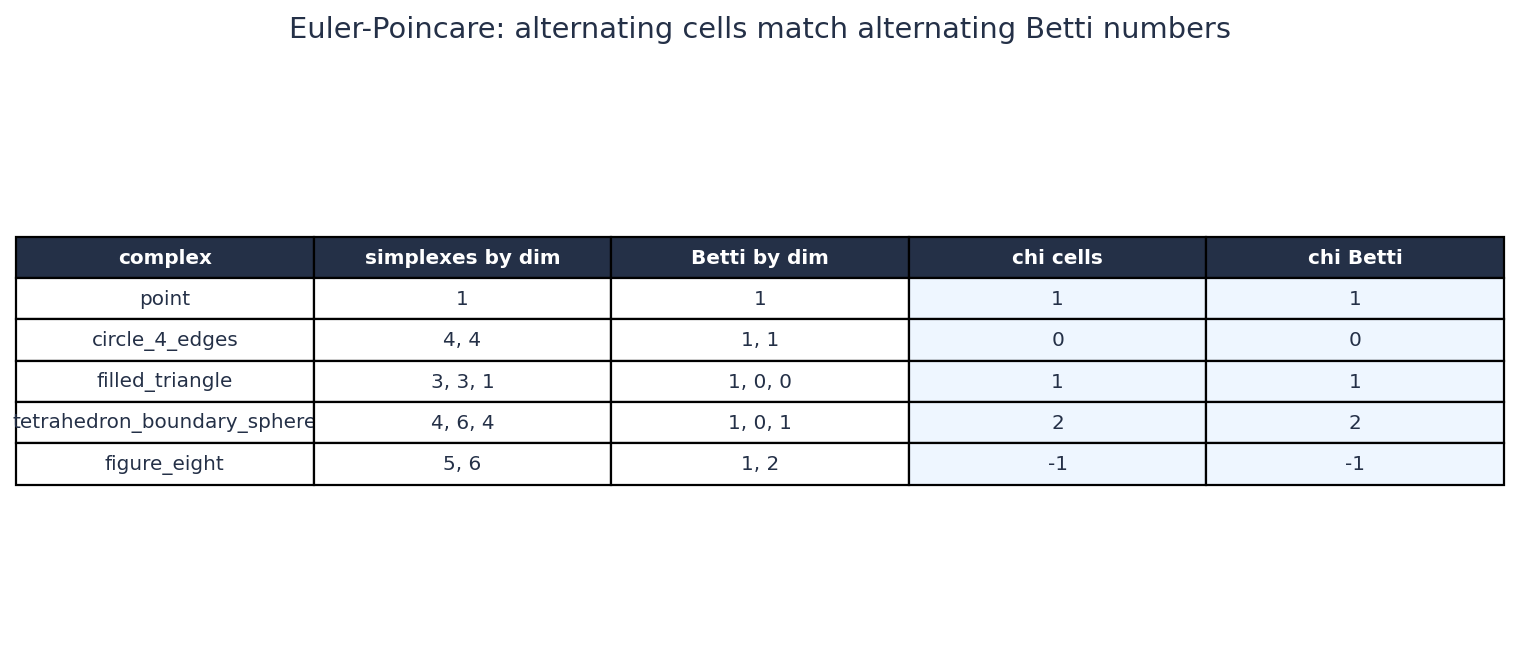

,complex,dimension,simplex_counts,boundary_ranks,betti,chi_cells,chi_betti
0,point,0,[1],[0],[1],1,1
1,circle_4_edges,1,"[4, 4]","[0, 3]","[1, 1]",0,0
2,filled_triangle,2,"[3, 3, 1]","[0, 2, 1]","[1, 0, 0]",1,1
3,tetrahedron_boundary_sphere,2,"[4, 6, 4]","[0, 3, 3]","[1, 0, 1]",2,2
4,figure_eight,1,"[5, 6]","[0, 4]","[1, 2]",-1,-1


In [5]:
def complex_from_facets(facets: list[tuple[int, ...]]) -> dict[int, list[tuple[int, ...]]]:
    closure: set[tuple[int, ...]] = set()
    for facet in facets:
        ordered = tuple(sorted(facet))
        for r in range(1, len(ordered) + 1):
            closure.update(tuple(c) for c in combinations(ordered, r))
    by_dim: dict[int, list[tuple[int, ...]]] = {}
    for simplex in closure:
        by_dim.setdefault(len(simplex) - 1, []).append(simplex)
    return {dim: sorted(simplices) for dim, simplices in by_dim.items()}


def exact_rank(matrix: np.ndarray) -> int:
    if matrix.size == 0:
        return 0
    return int(sp.Matrix(matrix).rank())


def boundary_for_complex(complex_by_dim: dict[int, list[tuple[int, ...]]], dim: int) -> np.ndarray:
    if dim <= 0:
        return np.zeros((0, len(complex_by_dim.get(0, []))), dtype=int)
    return boundary_matrix(complex_by_dim.get(dim, []), complex_by_dim.get(dim - 1, []))


def homology_ledger(name: str, facets: list[tuple[int, ...]]) -> dict[str, object]:
    complex_by_dim = complex_from_facets(facets)
    max_dim = max(complex_by_dim)
    counts = [len(complex_by_dim.get(q, [])) for q in range(max_dim + 1)]
    boundary_ranks = {q: exact_rank(boundary_for_complex(complex_by_dim, q)) for q in range(max_dim + 1)}
    betti = []
    for q in range(max_dim + 1):
        c_q = len(complex_by_dim.get(q, []))
        rank_out = boundary_ranks[q]
        rank_in = boundary_ranks.get(q + 1, 0)
        betti.append(int(c_q - rank_out - rank_in))
    chi_cells = int(sum(((-1) ** q) * counts[q] for q in range(len(counts))))
    chi_betti = int(sum(((-1) ** q) * betti[q] for q in range(len(betti))))
    return {
        "complex": name,
        "dimension": max_dim,
        "simplex_counts": counts,
        "boundary_ranks": [boundary_ranks[q] for q in range(max_dim + 1)],
        "betti": betti,
        "chi_cells": chi_cells,
        "chi_betti": chi_betti,
    }


complex_specs = {
    "point": [(0,)],
    "circle_4_edges": [(0, 1), (1, 2), (2, 3), (0, 3)],
    "filled_triangle": [(0, 1, 2)],
    "tetrahedron_boundary_sphere": [(0, 1, 2), (0, 1, 3), (0, 2, 3), (1, 2, 3)],
    "figure_eight": [(0, 1), (1, 2), (0, 2), (0, 3), (3, 4), (0, 4)],
}

ledger = [homology_ledger(name, facets) for name, facets in complex_specs.items()]
ledger_df = pd.DataFrame(ledger)
ledger_csv = artifact_path(UNIT, "tables", "euler-poincare-ledger.csv")
ledger_df.to_csv(ledger_csv, index=False)

fig, ax = plt.subplots(figsize=(12, 4.6))
ax.axis("off")
show_df = ledger_df.copy()
show_df["simplex_counts"] = show_df["simplex_counts"].map(lambda xs: ", ".join(map(str, xs)))
show_df["betti"] = show_df["betti"].map(lambda xs: ", ".join(map(str, xs)))
show_df = show_df[["complex", "simplex_counts", "betti", "chi_cells", "chi_betti"]]
table = ax.table(cellText=show_df.values, colLabels=["complex", "simplexes by dim", "Betti by dim", "chi cells", "chi Betti"], loc="center", cellLoc="center")
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.55)
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_text_props(weight="bold", color="white")
        cell.set_facecolor(PALETTE["ink"])
    elif col in {3, 4}:
        cell.set_facecolor("#eef6ff")
ax.set_title("Euler-Poincare: alternating cells match alternating Betti numbers", pad=18, fontsize=13)
euler_fig = save_matplotlib(fig, UNIT, "figures", "euler-poincare-ledger.png")
plt.close(fig)

euler_checks = {
    "ledgers": ledger,
    "all_chi_match": bool((ledger_df["chi_cells"] == ledger_df["chi_betti"]).all()),
    "rank_field": "exact rational ranks via sympy.Matrix.rank",
}

display_artifact(euler_fig, width=940)
ledger_df

## Borsuk-Ulam Through an Antipodal Gap

For a scalar function on the circle, Borsuk-Ulam says that some antipodal pair has the same value. The computational witness is the antipodal gap

`gap(theta) = f(theta) - f(theta + pi)`.

It satisfies `gap(theta + pi) = -gap(theta)`. A continuous function that changes sign this way must cross zero. The zero is the antipodal pair where `f(theta) = f(theta + pi)`. Higher-dimensional versions replace this scalar gap with a vector-valued obstruction.


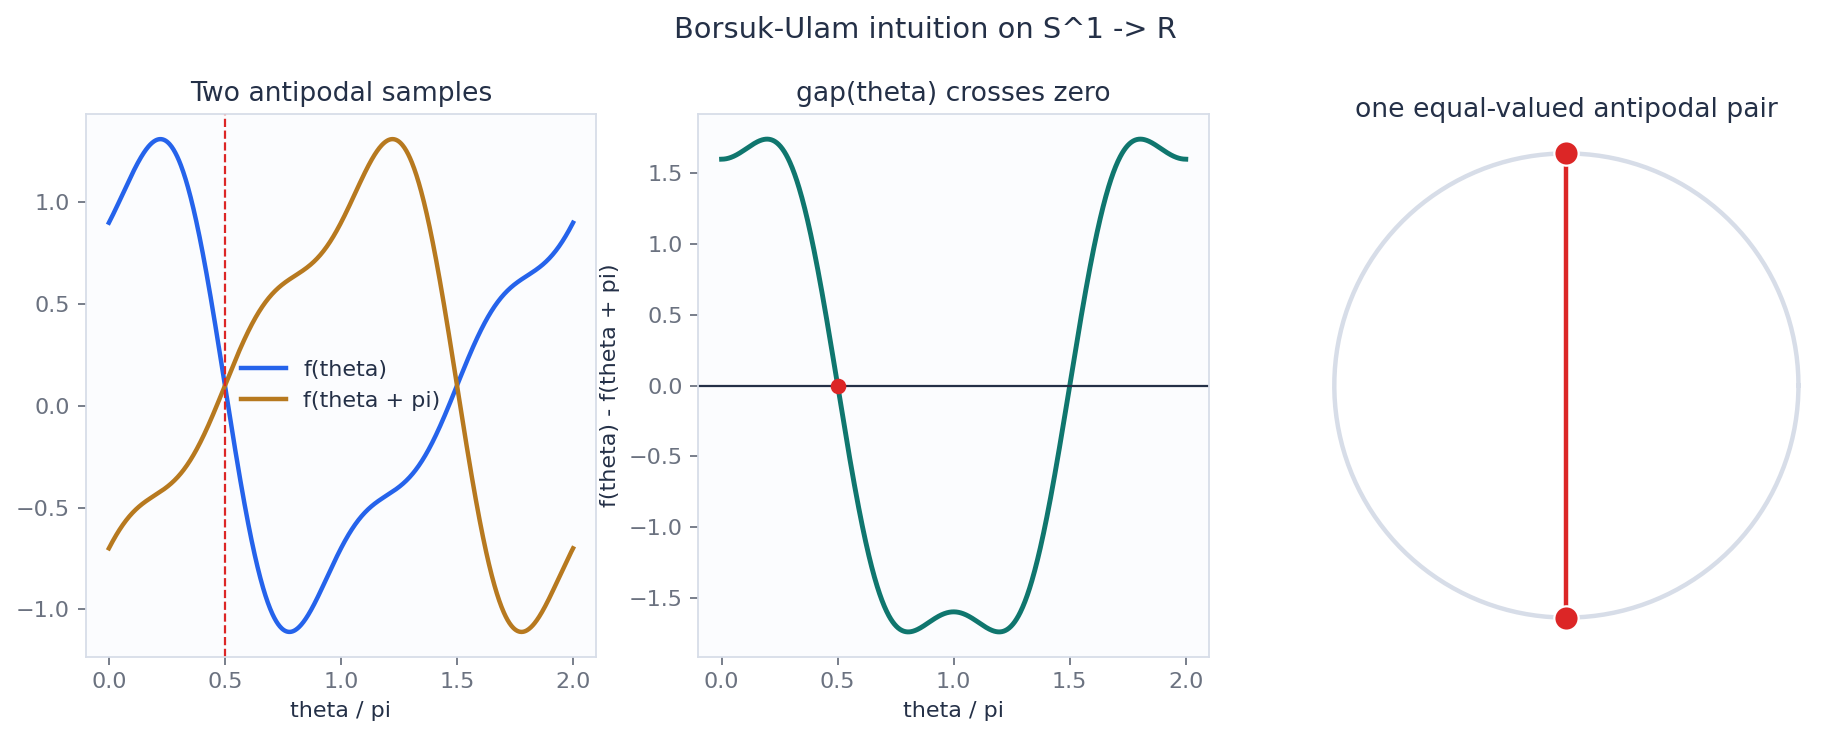

{'root_count_on_half_circle': 1,
 'roots_theta': [1.5707963267948968],
 'max_antiodd_error': 1.9984014443252818e-15,
 'first_root_values': {'f_theta': 0.09999999999999959,
  'f_antipode': 0.09999999999999984}}

In [6]:
def scalar_circle_map(t: np.ndarray | float) -> np.ndarray | float:
    return np.cos(t) + 0.35 * np.sin(2 * t) - 0.2 * np.cos(3 * t) + 0.1


def antipodal_gap(t: np.ndarray | float) -> np.ndarray | float:
    return scalar_circle_map(t) - scalar_circle_map(np.asarray(t) + np.pi)


def bisect_root(func, a: float, b: float, steps: int = 50) -> float:
    fa = float(func(a))
    fb = float(func(b))
    if abs(fa) < 1e-12:
        return a
    if abs(fb) < 1e-12:
        return b
    if fa * fb > 0:
        raise ValueError("interval does not bracket a root")
    lo, hi = a, b
    for _ in range(steps):
        mid = 0.5 * (lo + hi)
        fm = float(func(mid))
        if fa * fm <= 0:
            hi = mid
            fb = fm
        else:
            lo = mid
            fa = fm
    return 0.5 * (lo + hi)


grid = np.linspace(0, np.pi, 401)
gap_values = np.array([antipodal_gap(t) for t in grid], dtype=float)
roots = []
for a, b, fa, fb in zip(grid[:-1], grid[1:], gap_values[:-1], gap_values[1:]):
    if abs(fa) < 1e-8:
        roots.append(float(a))
    elif fa * fb < 0:
        roots.append(bisect_root(antipodal_gap, float(a), float(b)))
if abs(gap_values[-1]) < 1e-8:
    roots.append(float(grid[-1]))
unique_roots = []
for root in roots:
    if not unique_roots or abs(root - unique_roots[-1]) > 1e-4:
        unique_roots.append(root)

plot_t = np.linspace(0, 2 * np.pi, 1000)
fig, axes = plt.subplots(1, 3, figsize=(14, 4.4))
axes[0].plot(plot_t / np.pi, scalar_circle_map(plot_t), color=PALETTE["blue"], lw=2, label="f(theta)")
axes[0].plot(plot_t / np.pi, scalar_circle_map(plot_t + np.pi), color=PALETTE["gold"], lw=2, label="f(theta + pi)")
for root in unique_roots:
    axes[0].axvline(root / np.pi, color=PALETTE["red"], ls="--", lw=1)
axes[0].set_title("Two antipodal samples")
axes[0].set_xlabel("theta / pi")
axes[0].legend(frameon=False)

axes[1].plot(plot_t / np.pi, antipodal_gap(plot_t), color=PALETTE["teal"], lw=2.2)
axes[1].axhline(0, color=PALETTE["ink"], lw=1)
for root in unique_roots:
    axes[1].scatter([root / np.pi], [0], color=PALETTE["red"], zorder=4)
axes[1].set_title("gap(theta) crosses zero")
axes[1].set_xlabel("theta / pi")
axes[1].set_ylabel("f(theta) - f(theta + pi)")

axes[2].set_aspect("equal")
unit = np.linspace(0, 2 * np.pi, 300)
axes[2].plot(np.cos(unit), np.sin(unit), color=PALETTE["grid"], lw=2)
if unique_roots:
    r = unique_roots[0]
    points = np.array([[np.cos(r), np.sin(r)], [np.cos(r + np.pi), np.sin(r + np.pi)]])
    axes[2].plot(points[:, 0], points[:, 1], color=PALETTE["red"], lw=2)
    axes[2].scatter(points[:, 0], points[:, 1], s=120, color=PALETTE["red"], edgecolor="white", zorder=3)
axes[2].axis("off")
axes[2].set_title("one equal-valued antipodal pair")
fig.suptitle("Borsuk-Ulam intuition on S^1 -> R", y=1.02, fontsize=13)
borsuk_fig = save_matplotlib(fig, UNIT, "figures", "borsuk-ulam-antipodal-gap.png")
plt.close(fig)

shift_test = np.linspace(0, np.pi, 100)
antiodd_error = float(np.max(np.abs(antipodal_gap(shift_test + np.pi) + antipodal_gap(shift_test))))
borsuk_checks = {
    "root_count_on_half_circle": len(unique_roots),
    "roots_theta": unique_roots,
    "max_antiodd_error": antiodd_error,
    "first_root_values": None if not unique_roots else {
        "f_theta": float(scalar_circle_map(unique_roots[0])),
        "f_antipode": float(scalar_circle_map(unique_roots[0] + np.pi)),
    },
}

display_artifact(borsuk_fig, width=900)
borsuk_checks

## Lefschetz Number: Alternating Traces That Force Fixed Points

The Lefschetz number of a self-map is the alternating trace of the induced maps on rational homology. The chapter's fixed-point theorem says that a nonzero Lefschetz number cannot occur for a fixed-point-free map on a compact triangulable space.

For a circle map of degree `d`, the formula is `Lambda = 1 - d`. A reflection has degree `-1`, so `Lambda = 2`. The two fixed points in the artifact each contribute a positive local index in this smooth one-dimensional model. The point is not that every fixed point is counted geometrically in such a simple way, but that Lefschetz packages the total index into a homology trace.


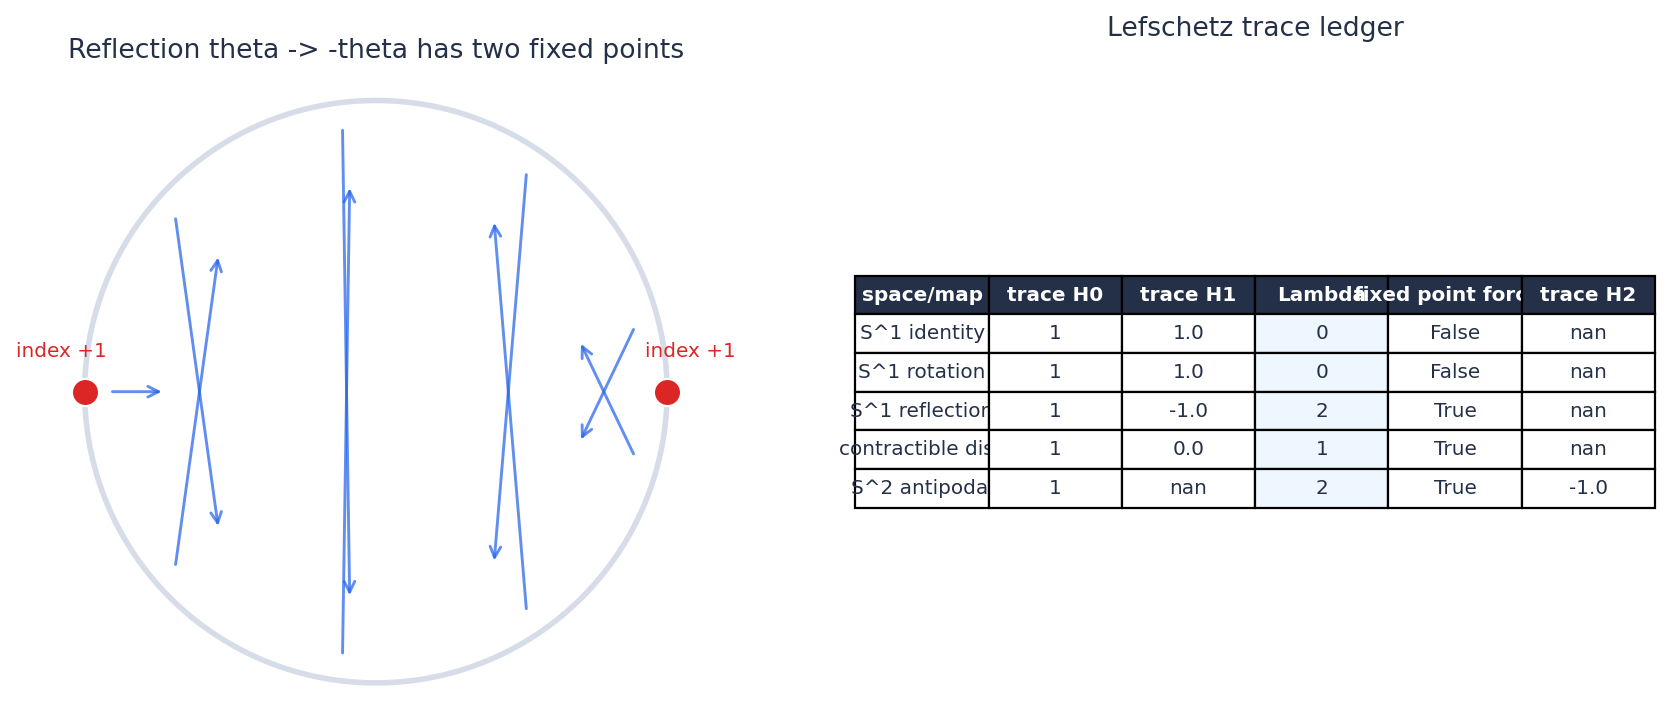

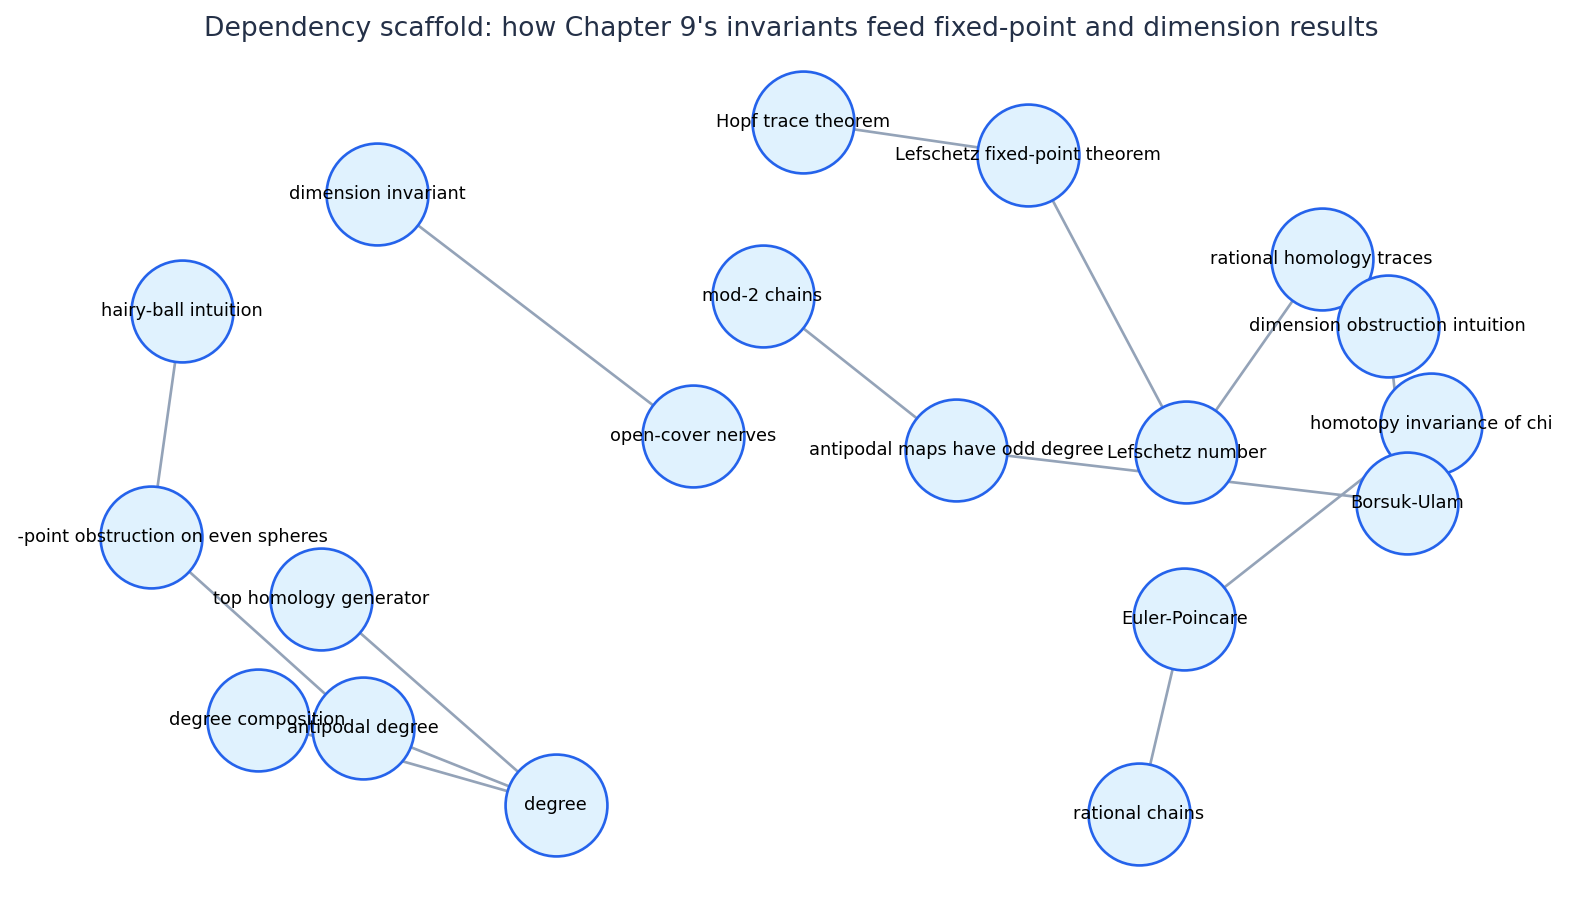

sphere_dim,1,2,3
degree,,,
-2,3,-1,3
-1,2,0,2
0,1,1,1
1,0,2,0
2,-1,3,-1


In [7]:
def lefschetz_sphere(n: int, degree: int) -> int:
    return int(1 + ((-1) ** n) * degree)


sphere_trace_rows = []
for n in [1, 2, 3]:
    for degree in [-2, -1, 0, 1, 2]:
        sphere_trace_rows.append({
            "sphere_dim": n,
            "degree": degree,
            "lefschetz": lefschetz_sphere(n, degree),
            "fixed_point_forced": lefschetz_sphere(n, degree) != 0,
        })
sphere_trace_df = pd.DataFrame(sphere_trace_rows)

reflection_lambda = int(chain_table.loc[chain_table["map"] == "reflection", "homology_alternating_trace"].iloc[0])
reflection_degree = int(chain_table.loc[chain_table["map"] == "reflection", "degree_on_H1"].iloc[0])

fig = plt.figure(figsize=(13, 5.2))
gs = fig.add_gridspec(1, 2, width_ratios=[1.0, 1.2])
ax_circle = fig.add_subplot(gs[0, 0])
ax_table = fig.add_subplot(gs[0, 1])

ax_circle.set_aspect("equal")
unit = np.linspace(0, 2 * np.pi, 300)
ax_circle.plot(np.cos(unit), np.sin(unit), color=PALETTE["grid"], lw=2.5)
for t in np.linspace(0.25, 2 * np.pi - 0.25, 9):
    source = np.array([np.cos(t), np.sin(t)])
    target = np.array([np.cos(-t), np.sin(-t)])
    arrow = FancyArrowPatch(source * 0.92, target * 0.72, arrowstyle="->", mutation_scale=12, color=PALETTE["blue"], lw=1.3, alpha=0.72)
    ax_circle.add_patch(arrow)
fixed_points = np.array([[1, 0], [-1, 0]])
ax_circle.scatter(fixed_points[:, 0], fixed_points[:, 1], s=150, color=PALETTE["red"], edgecolor="white", zorder=4)
for point, label in zip(fixed_points, ["index +1", "index +1"]):
    ax_circle.text(point[0] * 1.08, point[1] + 0.12, label, ha="center", fontsize=9, color=PALETTE["red"])
ax_circle.axis("off")
ax_circle.set_title("Reflection theta -> -theta has two fixed points")

ax_table.axis("off")
lefschetz_rows = pd.DataFrame([
    {"space/map": "S^1 identity", "trace H0": 1, "trace H1": 1, "Lambda": 0, "fixed point forced": False},
    {"space/map": "S^1 rotation", "trace H0": 1, "trace H1": 1, "Lambda": 0, "fixed point forced": False},
    {"space/map": "S^1 reflection", "trace H0": 1, "trace H1": -1, "Lambda": 2, "fixed point forced": True},
    {"space/map": "contractible disk", "trace H0": 1, "trace H1": 0, "Lambda": 1, "fixed point forced": True},
    {"space/map": "S^2 antipodal", "trace H0": 1, "trace H2": -1, "Lambda": 2, "fixed point forced": True},
])
table = ax_table.table(cellText=lefschetz_rows.values, colLabels=lefschetz_rows.columns, cellLoc="center", loc="center")
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.45)
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_text_props(weight="bold", color="white")
        cell.set_facecolor(PALETTE["ink"])
    elif col == 3 and row > 0:
        cell.set_facecolor("#eef6ff")
ax_table.set_title("Lefschetz trace ledger", pad=16)
lefschetz_fig = save_matplotlib(fig, UNIT, "figures", "lefschetz-reflection-fixed-points.png")
plt.close(fig)

proof_graph = nx.DiGraph()
proof_edges = [
    ("top homology generator", "degree"),
    ("degree", "degree composition"),
    ("degree", "antipodal degree"),
    ("antipodal degree", "fixed-point obstruction on even spheres"),
    ("fixed-point obstruction on even spheres", "hairy-ball intuition"),
    ("rational chains", "Euler-Poincare"),
    ("Euler-Poincare", "homotopy invariance of chi"),
    ("mod-2 chains", "antipodal maps have odd degree"),
    ("antipodal maps have odd degree", "Borsuk-Ulam"),
    ("rational homology traces", "Lefschetz number"),
    ("Hopf trace theorem", "Lefschetz fixed-point theorem"),
    ("Lefschetz number", "Lefschetz fixed-point theorem"),
    ("open-cover nerves", "dimension invariant"),
    ("Borsuk-Ulam", "dimension obstruction intuition"),
]
proof_graph.add_edges_from(proof_edges)
fig, ax = plt.subplots(figsize=(12.5, 6.8))
pos = nx.spring_layout(proof_graph, seed=9, k=0.95)
nx.draw_networkx_edges(proof_graph, pos, ax=ax, arrows=True, arrowstyle="-|>", width=1.2, edge_color="#94a3b8", arrowsize=13)
nx.draw_networkx_nodes(proof_graph, pos, ax=ax, node_size=2100, node_color="#e0f2fe", edgecolors=PALETTE["blue"], linewidths=1.2)
nx.draw_networkx_labels(proof_graph, pos, ax=ax, font_size=8)
ax.set_title("Dependency scaffold: how Chapter 9's invariants feed fixed-point and dimension results")
ax.axis("off")
proof_fig = save_matplotlib(fig, UNIT, "figures", "chapter-09-proof-dependency-map.png")
plt.close(fig)

lefschetz_checks = {
    "circle_reflection_degree": reflection_degree,
    "circle_reflection_lefschetz": reflection_lambda,
    "sphere_formula_samples": sphere_trace_df.to_dict(orient="records"),
    "hopf_trace_rows": chain_table.to_dict(orient="records"),
    "proof_graph_nodes": proof_graph.number_of_nodes(),
    "proof_graph_edges": proof_graph.number_of_edges(),
}

display_artifact(lefschetz_fig, width=920)
display_artifact(proof_fig, width=940)
sphere_trace_df.pivot(index="degree", columns="sphere_dim", values="lefschetz")

## Dimension by Nerves of Covers

The chapter closes by defining dimension through finite open covers and their nerves. A nerve is a simplicial complex whose vertices are open sets and whose simplexes record nonempty intersections.

A single cover can lie about dimension. The coarse circle cover below has a two-dimensional filled nerve because all three sets overlap together. A refinement by smaller arcs has a one-dimensional nerve, a cycle. The invariant dimension asks for refinements that keep the nerve dimension bounded.


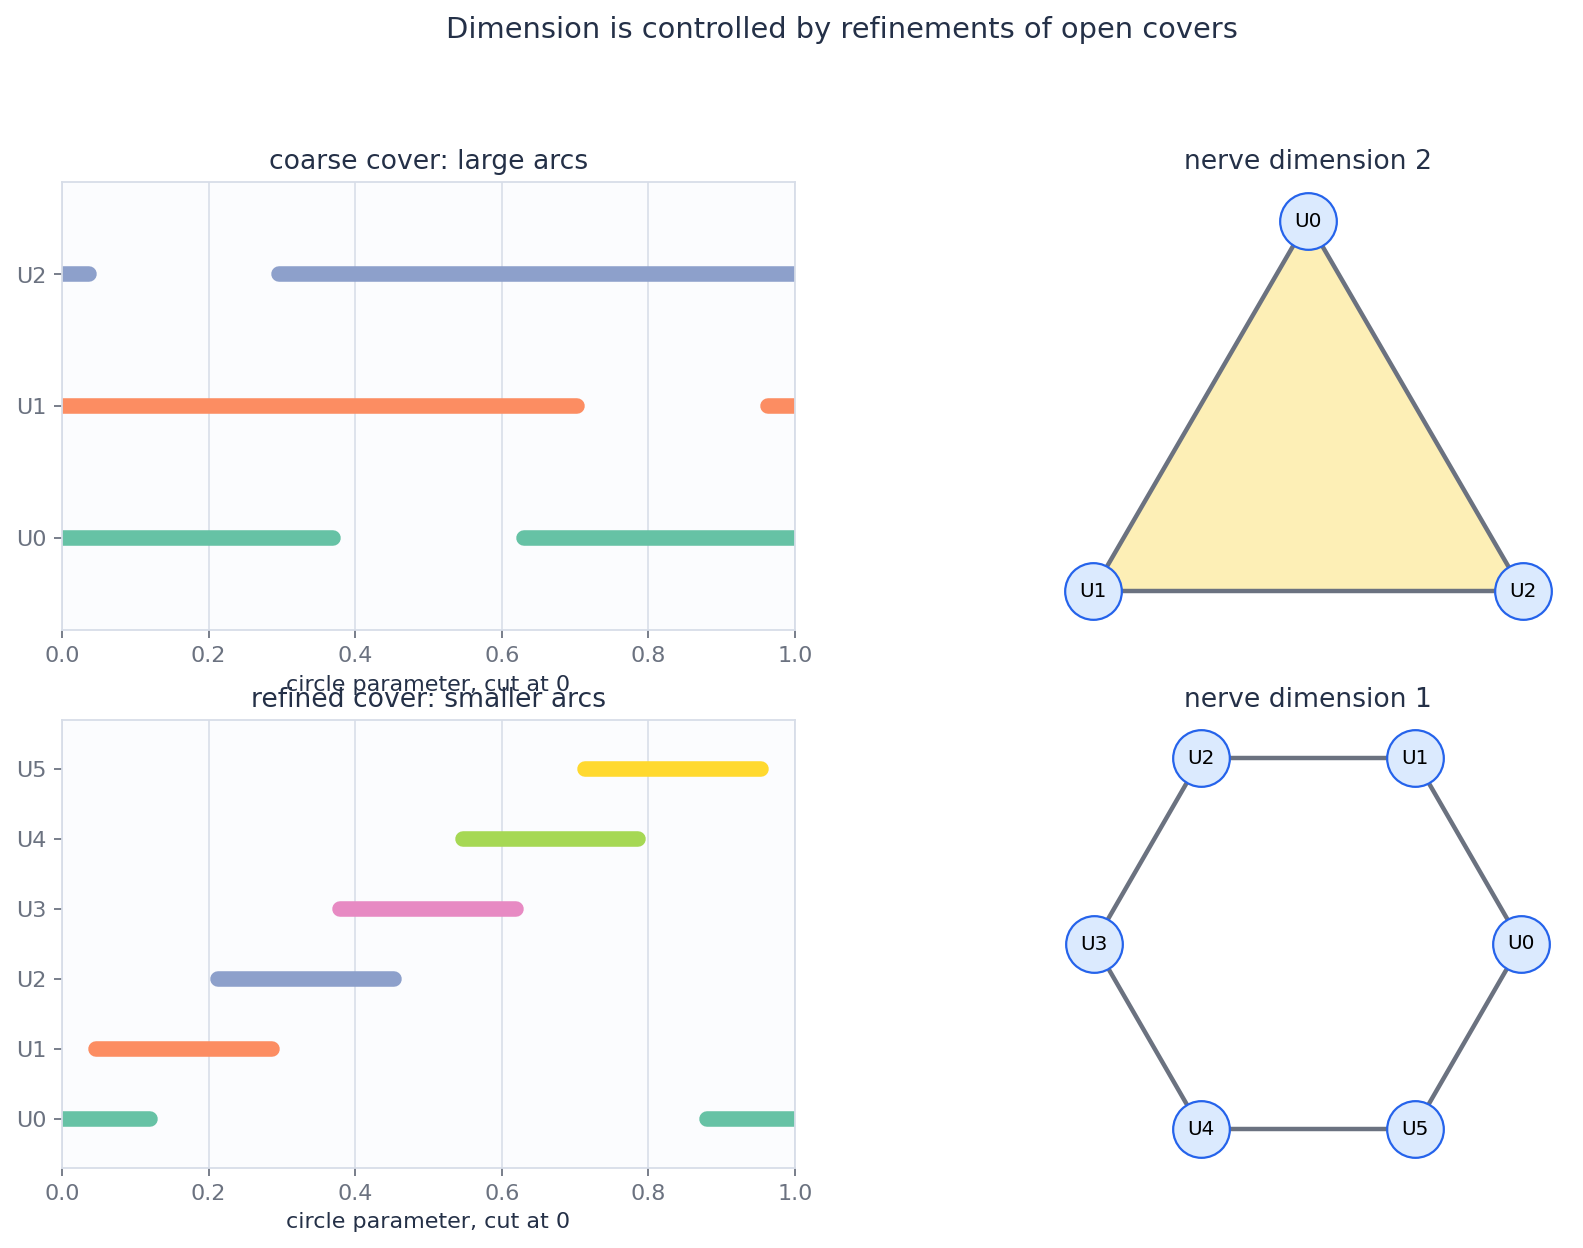

{'coarse_dimension': 2,
 'refined_dimension': 1,
 'coarse_covers_sample_grid': True,
 'refined_covers_sample_grid': True,
 'coarse_simplex_count': 7,
 'refined_simplex_count': 12}

In [8]:
def circular_distance(a: np.ndarray, b: float) -> np.ndarray:
    return np.abs(((a - b + 0.5) % 1.0) - 0.5)


def cover_mask(samples: np.ndarray, center: float, width: float) -> np.ndarray:
    return circular_distance(samples, center) < (width / 2)


def nerve_simplices(centers: list[float], width: float, samples: np.ndarray) -> list[tuple[int, ...]]:
    masks = [cover_mask(samples, center, width) for center in centers]
    simplices: list[tuple[int, ...]] = []
    for r in range(1, len(centers) + 1):
        for combo in combinations(range(len(centers)), r):
            if np.any(np.logical_and.reduce([masks[i] for i in combo])):
                simplices.append(combo)
    return simplices


def nerve_dimension(simplices: list[tuple[int, ...]]) -> int:
    return max(len(simplex) - 1 for simplex in simplices)


def draw_interval_cover(ax, centers: list[float], width: float, title: str) -> None:
    ax.set_title(title)
    ax.set_xlim(0, 1)
    ax.set_ylim(-0.7, len(centers) - 0.3)
    ax.set_xlabel("circle parameter, cut at 0")
    ax.set_yticks(range(len(centers)), [f"U{i}" for i in range(len(centers))])
    for i, center in enumerate(centers):
        start = center - width / 2
        end = center + width / 2
        segments = []
        if start < 0:
            segments.append((start + 1, 1))
            segments.append((0, end))
        elif end > 1:
            segments.append((start, 1))
            segments.append((0, end - 1))
        else:
            segments.append((start, end))
        for a, b in segments:
            ax.plot([a, b], [i, i], lw=7, solid_capstyle="round", color=plt.cm.Set2(i % 8))
    ax.grid(axis="x", color=PALETTE["grid"], lw=0.7)


def draw_nerve(ax, centers: list[float], simplices: list[tuple[int, ...]], title: str) -> None:
    graph = nx.Graph()
    graph.add_nodes_from(range(len(centers)))
    graph.add_edges_from([simplex for simplex in simplices if len(simplex) == 2])
    if len(centers) == 3:
        pos = {0: np.array([0, 1]), 1: np.array([-0.9, -0.55]), 2: np.array([0.9, -0.55])}
    else:
        pos = nx.circular_layout(graph)
    triangles = [simplex for simplex in simplices if len(simplex) == 3]
    for simplex in triangles:
        polygon = Polygon([pos[i] for i in simplex], closed=True, facecolor="#fde68a", edgecolor="none", alpha=0.62)
        ax.add_patch(polygon)
    nx.draw_networkx_edges(graph, pos, ax=ax, width=2.0, edge_color=PALETTE["muted"])
    nx.draw_networkx_nodes(graph, pos, ax=ax, node_color="#dbeafe", edgecolors=PALETTE["blue"], node_size=650)
    nx.draw_networkx_labels(graph, pos, ax=ax, labels={i: f"U{i}" for i in graph.nodes}, font_size=9)
    ax.set_title(title)
    ax.axis("off")
    ax.set_aspect("equal")


samples = np.linspace(0, 1, 2400, endpoint=False)
coarse_centers = [0.0, 1 / 3, 2 / 3]
coarse_width = 0.74
refined_centers = [i / 6 for i in range(6)]
refined_width = 0.24
coarse_nerve = nerve_simplices(coarse_centers, coarse_width, samples)
refined_nerve = nerve_simplices(refined_centers, refined_width, samples)

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
draw_interval_cover(axes[0, 0], coarse_centers, coarse_width, "coarse cover: large arcs")
draw_nerve(axes[0, 1], coarse_centers, coarse_nerve, f"nerve dimension {nerve_dimension(coarse_nerve)}")
draw_interval_cover(axes[1, 0], refined_centers, refined_width, "refined cover: smaller arcs")
draw_nerve(axes[1, 1], refined_centers, refined_nerve, f"nerve dimension {nerve_dimension(refined_nerve)}")
fig.suptitle("Dimension is controlled by refinements of open covers", y=1.01, fontsize=13)
nerve_fig = save_matplotlib(fig, UNIT, "figures", "nerve-refinement-dimension.png")
plt.close(fig)

coarse_masks = [cover_mask(samples, c, coarse_width) for c in coarse_centers]
refined_masks = [cover_mask(samples, c, refined_width) for c in refined_centers]
nerve_checks = {
    "coarse_dimension": nerve_dimension(coarse_nerve),
    "refined_dimension": nerve_dimension(refined_nerve),
    "coarse_covers_sample_grid": bool(np.all(np.logical_or.reduce(coarse_masks))),
    "refined_covers_sample_grid": bool(np.all(np.logical_or.reduce(refined_masks))),
    "coarse_simplex_count": len(coarse_nerve),
    "refined_simplex_count": len(refined_nerve),
}

display_artifact(nerve_fig, width=920)
nerve_checks

## Applied Lab: Read the Invariant Before Looking for the Point

The table below is a small decision engine for maps `S^n -> S^n`. Given only the dimension and degree, it computes the Lefschetz number `1 + (-1)^n degree`. A nonzero result guarantees a fixed point. A zero result does not guarantee no fixed points; it only means this invariant is silent.

This is the right habit for this chapter: first identify which homology group the map acts on, then ask whether the resulting trace can force the geometric conclusion.


In [9]:
lab_rows = []
for n in range(1, 5):
    for degree in range(-3, 4):
        lam = lefschetz_sphere(n, degree)
        lab_rows.append({
            "n": n,
            "degree": degree,
            "Lambda": lam,
            "fixed_point_forced_by_Lefschetz": lam != 0,
            "same_degree_as_antipodal": degree == (-1) ** (n + 1),
        })
lab_df = pd.DataFrame(lab_rows)
lab_csv = artifact_path(UNIT, "tables", "sphere-degree-lefschetz-lab.csv")
lab_df.to_csv(lab_csv, index=False)
lab_df.pivot(index="degree", columns="n", values="Lambda")

n,1,2,3,4
degree,,,,
-3,4,-2,4,-2
-2,3,-1,3,-1
-1,2,0,2,0
0,1,1,1,1
1,0,2,0,2
2,-1,3,-1,3
3,-2,4,-2,4


## Final Sanity Checks

These checks are part of the lesson. They verify the core algebraic identities, the trace formula on the explicit circle chain model, the Borsuk-Ulam antipodal-gap witness, the nerve dimensions, and the existence of every concept-named artifact displayed above.


In [10]:
artifact_paths = [
    degree_fig,
    composition_html,
    chain_fig,
    euler_fig,
    ledger_csv,
    borsuk_fig,
    lefschetz_fig,
    proof_fig,
    nerve_fig,
    lab_csv,
]

for path in artifact_paths:
    min_bytes = 64 if Path(path).suffix.lower() in {".csv", ".json"} else 1024
    assert_artifact(path, min_bytes=min_bytes)

assert degree_checks["composition"]["deg_composite_from_lift"] == degree_checks["composition"]["product"]
assert chain_checks["boundary_times_cycle"] == [0, 0, 0]
assert all(row["chain_alternating_trace"] == row["homology_alternating_trace"] for row in chain_checks["maps"])
assert euler_checks["all_chi_match"]
assert borsuk_checks["root_count_on_half_circle"] >= 1
assert borsuk_checks["max_antiodd_error"] < 1e-10
assert lefschetz_checks["circle_reflection_degree"] == -1
assert lefschetz_checks["circle_reflection_lefschetz"] == 2
assert nerve_checks["coarse_dimension"] == 2
assert nerve_checks["refined_dimension"] == 1
assert nerve_checks["coarse_covers_sample_grid"] and nerve_checks["refined_covers_sample_grid"]

invariant_summary = {
    "source_span": "Armstrong Basic Topology, printed pp. 195-212, PDF pages approximately 203-220",
    "degree_checks": degree_checks,
    "chain_checks": chain_checks,
    "euler_checks": euler_checks,
    "borsuk_ulam_checks": borsuk_checks,
    "lefschetz_checks": lefschetz_checks,
    "nerve_dimension_checks": nerve_checks,
    "artifacts": [rel(path) for path in artifact_paths],
}
checks_path = save_json(invariant_summary, UNIT, "checks", "chapter-09-invariants.json")
assert_artifact(checks_path, min_bytes=512)

pd.DataFrame([
    {"check_group": "degree", "status": "passed", "detail": degree_checks["composition"]},
    {"check_group": "chain maps", "status": "passed", "detail": "Hopf trace agrees on identity, rotation, reflection"},
    {"check_group": "Euler-Poincare", "status": "passed", "detail": f"{len(ledger_df)} finite complexes"},
    {"check_group": "Borsuk-Ulam", "status": "passed", "detail": borsuk_checks},
    {"check_group": "Lefschetz", "status": "passed", "detail": {"reflection_Lambda": reflection_lambda}},
    {"check_group": "dimension nerves", "status": "passed", "detail": nerve_checks},
    {"check_group": "artifacts", "status": "passed", "detail": rel(checks_path)},
])

,check_group,status,detail
0,degree,passed,"{'deg_f': 3, 'deg_g': -2, 'deg_composite_from_..."
1,chain maps,passed,"Hopf trace agrees on identity, rotation, refle..."
2,Euler-Poincare,passed,5 finite complexes
3,Borsuk-Ulam,passed,"{'root_count_on_half_circle': 1, 'roots_theta'..."
4,Lefschetz,passed,{'reflection_Lambda': 2}
5,dimension nerves,passed,"{'coarse_dimension': 2, 'refined_dimension': 1..."
6,artifacts,passed,artifacts/chapter-09/checks/chapter-09-invaria...


## Takeaways

- Degree is the integer by which a self-map of a sphere acts on top homology; on the circle it is visible as net winding of a lift.
- Composition multiplies degree because induced homology maps compose.
- Euler characteristic is homological: alternating cell counts equal alternating Betti numbers over the rationals.
- Borsuk-Ulam is an antipodal obstruction; in the scalar circle case the obstruction is the zero of an odd antipodal gap.
- Lefschetz numbers turn traces into fixed-point information. Nonzero `Lambda` forces a fixed point, while `Lambda = 0` only means this invariant is silent.
- Dimension can be phrased through nerves of finite covers; refinement is the mechanism that removes misleading high-dimensional intersections.
